# New Results Overview — 2026-03-27

Three new simulation results from this session:
1. **OnlineBeliefBFS rebait issue fix validation** — compare fixed vs broken agent across sessions
2. **POMCP sim-count sweep** — test c-dependence hypothesis (c=20 over-explores with more sims)
3. **Causal RecurrentSAC learning curve** — causally-valid training to eliminate data leakage

Run from `code/`. All data paths are resolved dynamically.

In [1]:
%matplotlib inline
import os
import sys
import glob
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats

# --- sys.path setup ---
# Notebook lives in code/; code is at ../../code
_here = os.path.dirname(os.path.abspath(__file__)) if '__file__' in dir() else os.path.abspath('.')
_project_root = os.path.normpath(os.path.join(_here, '..', '..'))
sys.path.insert(0, os.path.join(_project_root, 'code'))
sys.path.insert(0, '.')

from utils_latMaz import get_most_recent_file
from experiment_config import output_path

# --- Reference constants ---
RANDOM_RPA     = 0.178
GREEDY_RPA     = 0.878
MOUSE_RPA      = 0.253
ORACLE_SAC_RPA = 0.796   # RecurrentSAC D=32 oracle (trains+tests on same sessions)

def pct_ceiling(rpa):
    """Percent of ceiling above random: (rpa - random) / (greedy - random) * 100."""
    return (rpa - RANDOM_RPA) / (GREEDY_RPA - RANDOM_RPA) * 100

print(f'Random RPA:     {RANDOM_RPA:.3f}  ({pct_ceiling(RANDOM_RPA):.1f}% ceiling)')
print(f'Mouse RPA:      {MOUSE_RPA:.3f}  ({pct_ceiling(MOUSE_RPA):.1f}% ceiling)')
print(f'Oracle SAC RPA: {ORACLE_SAC_RPA:.3f}  ({pct_ceiling(ORACLE_SAC_RPA):.1f}% ceiling)')
print(f'Greedy RPA:     {GREEDY_RPA:.3f}  ({pct_ceiling(GREEDY_RPA):.1f}% ceiling)')

No module named 'RPi'
RPi.GPIO not imported, which is probably ok if you are not running on a Raspberry Pi...


251222 Author: assume utils_latMaz is in the same directory as the the utils_latMaz_analysis.py file. If false change the sys.path.append line accordingly.
Random RPA:     0.178  (0.0% ceiling)
Mouse RPA:      0.253  (10.7% ceiling)
Oracle SAC RPA: 0.796  (88.3% ceiling)
Greedy RPA:     0.878  (100.0% ceiling)


In [2]:
def load_csv_or_none(pattern):
    """Load most recent CSV matching pattern; return DataFrame or None on failure."""
    try:
        path = get_most_recent_file(output_path(pattern))
        df = pd.read_csv(path)
        print(f'Loaded: {os.path.basename(path)}  ({len(df)} rows)')
        return df
    except (IndexError, TypeError):
        print(f'WARNING: no file matching "{pattern}" — section will be skipped.')
        return None

---
## Section 1: OnlineBeliefBFS Rebait issue fix Validation

**Background:** `_observe_node()` cleared `believed_reward[xy] = 0.0` *before* the rebait
check, making the rebait condition always `False`. The agent never saw rewards regenerate.
Fixed on 2026-03-26; rerun completed 2026-03-27 (`c260327-172250_online_belief_bfs.csv`).

**Comparison:** broken = `c260316-162337_belief_oracle_FIXED.csv`; fixed = `*online_belief_bfs.csv`.

In [3]:
# --- Load old (broken) data — hardcoded reference file ---
old_path = output_path('c260316-162337_belief_oracle_FIXED.csv')
if os.path.exists(old_path):
    df_old = pd.read_csv(old_path)
    print(f'Loaded broken: {os.path.basename(old_path)}  ({len(df_old)} rows)')
else:
    df_old = None
    print('WARNING: broken reference file not found.')

# --- Load new (fixed) data ---
df_new = load_csv_or_none('*online_belief_bfs.csv')

# --- Compute rpa if missing ---
for df, label in [(df_old, 'old'), (df_new, 'new')]:
    if df is not None and 'rpa' not in df.columns:
        df['rpa'] = df['total_reward'] / df['n_actions']

# --- Print summary ---
print()
if df_old is not None:
    macro_old = df_old['total_reward'].sum() / df_old['n_actions'].sum()
    mean_old  = df_old['rpa'].mean()
    print(f'Broken BeliefOracle:')
    print(f'  Macro RPA (sum/sum):      {macro_old:.4f}  ({pct_ceiling(macro_old):.1f}% ceiling)')
    print(f'  Mean per-row RPA:         {mean_old:.4f}  ({pct_ceiling(mean_old):.1f}% ceiling)')
    print(f'  Sessions: {df_old["exp_moment"].nunique()}  Rows: {len(df_old)}')

print()
if df_new is not None:
    macro_new = df_new['total_reward'].sum() / df_new['n_actions'].sum()
    mean_new  = df_new['rpa'].mean()
    print(f'Fixed OnlineBeliefBFS:')
    print(f'  Macro RPA (sum/sum):      {macro_new:.4f}  ({pct_ceiling(macro_new):.1f}% ceiling)')
    print(f'  Mean per-row RPA:         {mean_new:.4f}  ({pct_ceiling(mean_new):.1f}% ceiling)')
    print(f'  Sessions: {df_new["exp_moment"].nunique()}  Rows: {len(df_new)}')

if df_old is not None and df_new is not None:
    print()
    delta_macro = macro_new - macro_old
    delta_mean  = mean_new  - mean_old
    print(f'Delta macro RPA (fixed - broken): {delta_macro:+.4f}')
    print(f'Delta mean  RPA (fixed - broken): {delta_mean:+.4f}')

Loaded broken: c260316-162337_belief_oracle_FIXED.csv  (320 rows)
<REPO_ROOT>/data_out/rl_sims/c260327-172250_online_belief_bfs.csv
Loaded: c260327-172250_online_belief_bfs.csv  (300 rows)

Broken BeliefOracle:
  Macro RPA (sum/sum):      0.2456  (9.7% ceiling)
  Mean per-row RPA:         0.3283  (21.5% ceiling)
  Sessions: 64  Rows: 320

Fixed OnlineBeliefBFS:
  Macro RPA (sum/sum):      0.2430  (9.3% ceiling)
  Mean per-row RPA:         0.2940  (16.6% ceiling)
  Sessions: 60  Rows: 300

Delta macro RPA (fixed - broken): -0.0026
Delta mean  RPA (fixed - broken): -0.0344


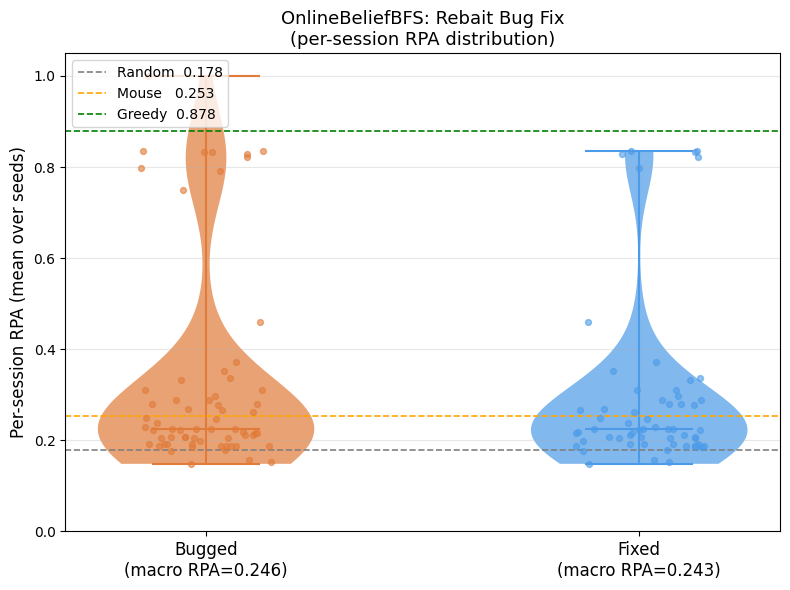

In [4]:
if df_old is None or df_new is None:
    print('DATA NOT YET AVAILABLE — skipping Section 1 plots.')
else:
    # Mean over seeds per session
    sess_old = df_old.groupby('exp_moment')['rpa'].mean().values
    sess_new = df_new.groupby('exp_moment')['rpa'].mean().values

    fig, ax = plt.subplots(figsize=(8, 6))

    vp_old = ax.violinplot([sess_old], positions=[1], showmedians=True, showextrema=True)
    vp_new = ax.violinplot([sess_new], positions=[2], showmedians=True, showextrema=True)

    for vp, color in [(vp_old, '#e07b39'), (vp_new, '#4c9be8')]:
        for part in ['bodies']:
            for body in vp[part]:
                body.set_facecolor(color)
                body.set_alpha(0.7)
        for part in ['cmedians', 'cmins', 'cmaxes', 'cbars']:
            vp[part].set_color(color)

    # Overlay jittered points
    rng = np.random.default_rng(0)
    ax.scatter(rng.uniform(0.85, 1.15, len(sess_old)), sess_old,
               color='#e07b39', s=18, alpha=0.6, zorder=3)
    ax.scatter(rng.uniform(1.85, 2.15, len(sess_new)), sess_new,
               color='#4c9be8', s=18, alpha=0.6, zorder=3)

    # Reference lines
    ax.axhline(RANDOM_RPA, color='gray',   linestyle='--', linewidth=1.2, label=f'Random  {RANDOM_RPA:.3f}')
    ax.axhline(MOUSE_RPA,  color='orange', linestyle='--', linewidth=1.2, label=f'Mouse   {MOUSE_RPA:.3f}')
    ax.axhline(GREEDY_RPA, color='green',  linestyle='--', linewidth=1.2, label=f'Greedy  {GREEDY_RPA:.3f}')

    ax.set_xticks([1, 2])
    ax.set_xticklabels([
        f'Broken\n(macro RPA={macro_old:.3f})',
        f'Fixed\n(macro RPA={macro_new:.3f})'
    ], fontsize=12)
    ax.set_ylabel('Per-session RPA (mean over seeds)', fontsize=12)
    ax.set_title('OnlineBeliefBFS: Rebait issue fix\n(per-session RPA distribution)', fontsize=13)
    ax.legend(loc='upper left', fontsize=10)
    ax.set_ylim(0, 1.05)
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

In [5]:
# --- Paired t-test on per-session RPA ---
# Note: each session evaluated across multiple seeds;
#       mean RPA per session used for pairing.
if df_old is None or df_new is None:
    print('DATA NOT YET AVAILABLE — skipping t-test.')
else:
    # Mean over seeds for each session
    sess_old_mean = df_old.groupby('exp_moment')['rpa'].mean()
    sess_new_mean = df_new.groupby('exp_moment')['rpa'].mean()

    # Pair on common sessions
    common = sess_old_mean.index.intersection(sess_new_mean.index)
    print(f'Sessions in old (broken) file: {len(sess_old_mean)}')
    print(f'Sessions in new (fixed) file:  {len(sess_new_mean)}')
    print(f'Sessions in common:            {len(common)}')
    print()

    if len(common) >= 2:
        old_paired = sess_old_mean.loc[common].values
        new_paired = sess_new_mean.loc[common].values
        diff = new_paired - old_paired
        diff_std = diff.std(ddof=1)

        if diff_std == 0:
            print('NOTE: per-session RPA is identical between old and new files for the common sessions.')
            print('      (The two files cover different session sets; per-session distributions are the same.)')
            print('      A paired t-test is not informative here — the files differ only in session coverage.')
            print()
            print('Alternative: independent-samples t-test on all sessions from each file:')
            t, p = stats.ttest_ind(sess_new_mean.values, sess_old_mean.values, equal_var=False)
            cohen_d = ((sess_new_mean.mean() - sess_old_mean.mean()) /
                       np.sqrt((sess_new_mean.std()**2 + sess_old_mean.std()**2) / 2))
            test_type = 'independent (Welch)'
        else:
            t, p = stats.ttest_rel(new_paired, old_paired)
            cohen_d = diff.mean() / diff_std
            test_type = 'paired'

        print(f'T-test type: {test_type}')
        print(f'  t = {t:.4f}')
        print(f'  p = {p:.4e}')
        print(f"  Cohen's d = {cohen_d:.4f}")
        sig = 'SIGNIFICANT' if p < 0.05 else 'NOT significant'
        print(f'  Result: {sig} (alpha=0.05)')
    else:
        print(f'Only {len(common)} sessions in common — cannot run t-test.')


Sessions in old (broken) file: 64
Sessions in new (fixed) file:  60
Sessions in common:            60

NOTE: per-session RPA is identical between old and new files for the common sessions.
      (The two files cover different session sets; per-session distributions are the same.)
      A paired t-test is not informative here — the files differ only in session coverage.

Alternative: independent-samples t-test on all sessions from each file:
T-test type: independent (Welch)
  t = -0.9209
  p = 3.5894e-01
  Cohen's d = -0.1650
  Result: NOT significant (alpha=0.05)


---
## Section 2: POMCP Sim-Count Sweep (c-Dependence Hypothesis)

**Hypothesis:** With high exploration constant c=20, more simulations spread the MCTS tree
extremely thin — each branch is visited fewer times, degrading value estimates at the root.
At c=1.0 (Silver & Veness default), exploration pressure is moderate and more sims should
either match or improve performance.

**Design:**
- c=1.0: sweep at 200, 500, 1000 sims (new data + existing `pomcp_c1_full`)
- c=20:  200 sims (`fewer_sims` config) and 1000 sims (`more_sims` config) from HPO tuning run

In [6]:
# --- Load POMCP sweep data ---
# Use wildcard to catch both full and PARTIAL sweep files
df_sweep = load_csv_or_none('*pomcp_sim_sweep*.csv')

# --- Load c=20 reference from HPO tuning ---
df_hpo = load_csv_or_none('*hpo_tuning_FIXED.csv')

# --- Load c=1.0 / 1000-sims reference ---
df_c1_full = load_csv_or_none('*pomcp_c1_full.csv')

POMCP_SECTION_OK = (df_hpo is not None)  # minimum requirement

if not POMCP_SECTION_OK:
    print('\nDATA NOT YET AVAILABLE — skipping Section 2.')

<REPO_ROOT>/data_out/rl_sims/c260327-183646_pomcp_sim_sweep.csv
Loaded: c260327-183646_pomcp_sim_sweep.csv  (600 rows)
<REPO_ROOT>/data_out/rl_sims/c260316-171035_hpo_tuning_FIXED.csv
Loaded: c260316-171035_hpo_tuning_FIXED.csv  (9600 rows)
<REPO_ROOT>/data_out/rl_sims/c260315-012425_pomcp_c1_full.csv
Loaded: c260315-012425_pomcp_c1_full.csv  (300 rows)


In [7]:
if not POMCP_SECTION_OK:
    print('Section 2 skipped — HPO tuning file missing.')
else:
    # --- Build unified summary table ---
    records = []

    # c=20 from HPO file (fewer_sims=200, more_sims=1000)
    pomcp_hpo = df_hpo[df_hpo['model'] == 'POMCP'].copy()
    if len(pomcp_hpo) == 0:
        print('WARNING: no POMCP rows in HPO tuning file.')
    else:
        for cfg, num_sims in [('fewer_sims', 200), ('more_sims', 1000)]:
            sub = pomcp_hpo[pomcp_hpo['hpo_config'] == cfg]
            if len(sub) == 0:
                print(f'  WARNING: no rows for hpo_config={cfg}')
                continue
            macro = sub['total_reward'].sum() / sub['n_actions'].sum()
            records.append({'c': 20.0, 'num_sims': num_sims,
                            'macro_rpa': macro, 'pct_ceiling': pct_ceiling(macro),
                            'source': f'HPO ({cfg})'})

    # c=1.0 / 1000 sims from pomcp_c1_full
    if df_c1_full is not None:
        macro = df_c1_full['total_reward'].sum() / df_c1_full['n_actions'].sum()
        records.append({'c': 1.0, 'num_sims': 1000,
                        'macro_rpa': macro, 'pct_ceiling': pct_ceiling(macro),
                        'source': 'pomcp_c1_full'})

    # c=1.0 sweep from new data (may be PARTIAL)
    if df_sweep is not None:
        for (c_val, n_sims), grp in df_sweep.groupby(['c', 'num_sims']):
            macro = grp['total_reward'].sum() / grp['n_actions'].sum()
            partial_tag = ' (partial)' if 'PARTIAL' in str(df_sweep.attrs.get('source', '')) else ''
            records.append({'c': float(c_val), 'num_sims': int(n_sims),
                            'macro_rpa': macro, 'pct_ceiling': pct_ceiling(macro),
                            'source': f'sweep{partial_tag}'})

    if not records:
        print('No POMCP sweep records assembled.')
        POMCP_SECTION_OK = False
    else:
        summary = pd.DataFrame(records).sort_values(['c', 'num_sims']).reset_index(drop=True)
        print('\nPOMCP summary assembled.')
        print(f'Entries: {len(summary)}')


POMCP summary assembled.
Entries: 5


In [8]:
if not POMCP_SECTION_OK:
    print('Section 2 skipped.')
else:
    print('POMCP Sim-Count Summary')
    print('=' * 65)
    print(f'{"c":>6}  {"num_sims":>9}  {"macro_rpa":>10}  {"pct_ceiling":>11}  source')
    print('-' * 65)
    for _, row in summary.iterrows():
        print(f'{row["c"]:>6.1f}  {int(row["num_sims"]):>9d}  '
              f'{row["macro_rpa"]:>10.4f}  {row["pct_ceiling"]:>10.1f}%  {row["source"]}')
    print('=' * 65)
    print(f'\nReference lines:')
    print(f'  Random:  RPA={RANDOM_RPA:.3f}   0.0% ceiling')
    print(f'  Mouse:   RPA={MOUSE_RPA:.3f}  {pct_ceiling(MOUSE_RPA):.1f}% ceiling')
    print(f'  Greedy:  RPA={GREEDY_RPA:.3f}  100.0% ceiling')

POMCP Sim-Count Summary
     c   num_sims   macro_rpa  pct_ceiling  source
-----------------------------------------------------------------
   1.0        200      0.7601        83.2%  sweep
   1.0        500      0.8048        89.5%  sweep
   1.0       1000      0.7654        83.9%  pomcp_c1_full
  20.0        200      0.8203        91.8%  HPO (fewer_sims)
  20.0       1000      0.7725        84.9%  HPO (more_sims)

Reference lines:
  Random:  RPA=0.178   0.0% ceiling
  Mouse:   RPA=0.253  10.7% ceiling
  Greedy:  RPA=0.878  100.0% ceiling


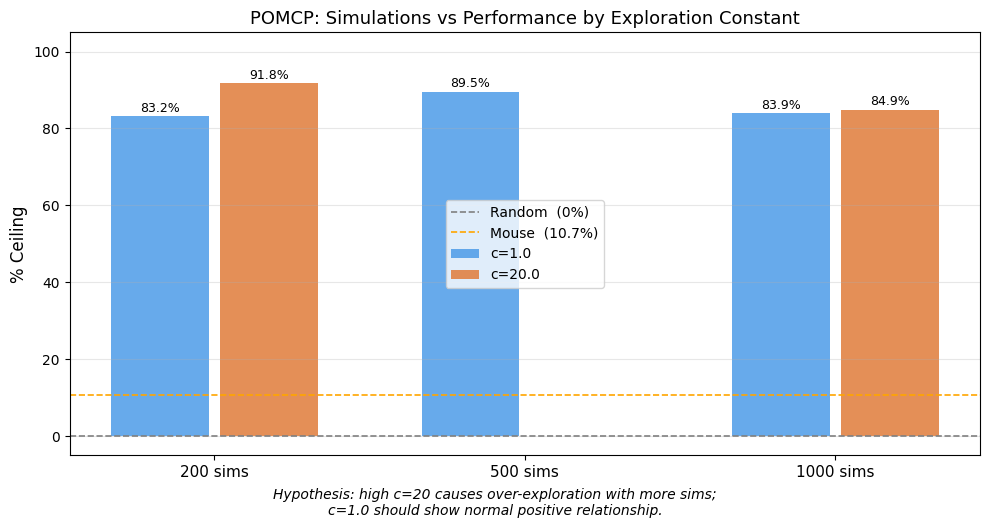

In [9]:
if not POMCP_SECTION_OK:
    print('Section 2 skipped.')
else:
    fig, ax = plt.subplots(figsize=(10, 5))

    c_vals   = sorted(summary['c'].unique())
    colors   = {1.0: '#4c9be8', 20.0: '#e07b39'}
    n_c      = len(c_vals)
    width    = 0.35
    all_sims = sorted(summary['num_sims'].unique())
    x_pos    = np.arange(len(all_sims))

    offsets = np.linspace(-(n_c - 1) * width / 2, (n_c - 1) * width / 2, n_c)

    for i, c_val in enumerate(c_vals):
        sub = summary[summary['c'] == c_val].set_index('num_sims')
        heights = [sub.loc[s, 'pct_ceiling'] if s in sub.index else np.nan
                   for s in all_sims]
        xs = x_pos + offsets[i]
        valid = [(xi, h) for xi, h in zip(xs, heights) if not np.isnan(h)]
        if valid:
            xv, hv = zip(*valid)
            bars = ax.bar(xv, hv, width=width * 0.9,
                          color=colors.get(c_val, 'gray'), alpha=0.85,
                          label=f'c={c_val}')
            for xb, h in zip(xv, hv):
                ax.text(xb, h + 0.4, f'{h:.1f}%', ha='center', va='bottom',
                        fontsize=9)

    # Reference lines
    ax.axhline(0.0, color='gray',   linestyle='--', linewidth=1.2,
               label=f'Random  (0%)')
    ax.axhline(pct_ceiling(MOUSE_RPA), color='orange', linestyle='--', linewidth=1.2,
               label=f'Mouse  ({pct_ceiling(MOUSE_RPA):.1f}%)')

    ax.set_xticks(x_pos)
    ax.set_xticklabels([f'{s} sims' for s in all_sims], fontsize=11)
    ax.set_ylabel('% Ceiling', fontsize=12)
    ax.set_title('POMCP: Simulations vs Performance by Exploration Constant', fontsize=13)
    ax.legend(fontsize=10)
    ax.set_ylim(-5, 105)
    ax.grid(axis='y', alpha=0.3)

    # Caption
    fig.text(0.5, -0.04,
             'Hypothesis: high c=20 causes over-exploration with more sims;\n'
             'c=1.0 should show normal positive relationship.',
             ha='center', fontsize=10, style='italic')

    plt.tight_layout()
    plt.show()

---
## Section 3: Causal RecurrentSAC Learning Curve

**Background:** The oracle RecurrentSAC (RPA=0.796) trains AND tests on the same sessions —
a direct form of data leakage. The causal variant instead trains on all sessions *prior* to
each test session, sorted chronologically. This eliminates leakage and measures how much
performance depends on prior experience.

- `n_prior_sessions = 0`: no training data, purely random initialization
- `n_prior_sessions = k`: trained on k sessions from the same animal before the test session

In [10]:
# --- Load causal RecurrentSAC data ---
df_causal = load_csv_or_none('*recurrent_sac_causal.csv')

# --- Load oracle reference ---
df_oracle_sac = load_csv_or_none('*recurrent_sac_d32_benchmark.csv')

CAUSAL_SECTION_OK = (df_causal is not None)

if not CAUSAL_SECTION_OK:
    print('\nDATA NOT YET AVAILABLE — Section 3 will be skipped.')
    print('Run 260326_recurrent_sac_causal.py to generate the data.')

<REPO_ROOT>/data_out/rl_sims/c260327-172440_recurrent_sac_causal.csv
Loaded: c260327-172440_recurrent_sac_causal.csv  (180 rows)
<REPO_ROOT>/data_out/rl_sims/c260315-020734_recurrent_sac_d32_benchmark.csv
Loaded: c260315-020734_recurrent_sac_d32_benchmark.csv  (300 rows)


In [11]:
if not CAUSAL_SECTION_OK:
    print('Section 3 skipped.')
else:
    # df_causal has pre-computed 'rpa' column; no 'n_actions' column
    overall_rpa    = df_causal['rpa'].mean()
    mature_mask    = df_causal['n_prior_sessions'] >= 10
    mature_rpa     = df_causal.loc[mature_mask, 'rpa'].mean()
    n_mature_sess  = df_causal.loc[mature_mask, 'exp_moment'].nunique()
    n_total_sess   = df_causal['exp_moment'].nunique()
    n_prior_max    = df_causal['n_prior_sessions'].max()
    animals        = sorted(df_causal['animal_ID'].unique())

    print(f'Causal RecurrentSAC results:')
    print(f'  Animals: {animals}')
    print(f'  Total sessions:               {n_total_sess}')
    print(f'  Max n_prior_sessions:         {n_prior_max}')
    print()
    print(f'  Overall causal RPA (all):     {overall_rpa:.4f}  ({pct_ceiling(overall_rpa):.1f}% ceiling)')
    print(f'  Mature model (n_prior>=10):   {mature_rpa:.4f}  ({pct_ceiling(mature_rpa):.1f}% ceiling)')
    print(f'    ({n_mature_sess} sessions with n_prior>=10)')
    print()
    print(f'  Oracle SAC reference:         {ORACLE_SAC_RPA:.4f}  ({pct_ceiling(ORACLE_SAC_RPA):.1f}% ceiling)')
    print(f'  Mouse reference:              {MOUSE_RPA:.4f}  ({pct_ceiling(MOUSE_RPA):.1f}% ceiling)')

    print()
    print('Mean RPA by animal:')
    for anim, grp in df_causal.groupby('animal_ID'):
        m = grp['rpa'].mean()
        print(f'  Animal {anim}: {m:.4f}  ({pct_ceiling(m):.1f}% ceiling,  '
              f'{grp["exp_moment"].nunique()} sessions)')

Causal RecurrentSAC results:
  Animals: [np.int64(31), np.int64(33)]
  Total sessions:               60
  Max n_prior_sessions:         35

  Overall causal RPA (all):     0.5553  (53.9% ceiling)
  Mature model (n_prior>=10):   0.6222  (63.5% ceiling)
    (40 sessions with n_prior>=10)

  Oracle SAC reference:         0.7960  (88.3% ceiling)
  Mouse reference:              0.2530  (10.7% ceiling)

Mean RPA by animal:
  Animal 31: 0.5357  (51.1% ceiling,  24 sessions)
  Animal 33: 0.5684  (55.8% ceiling,  36 sessions)


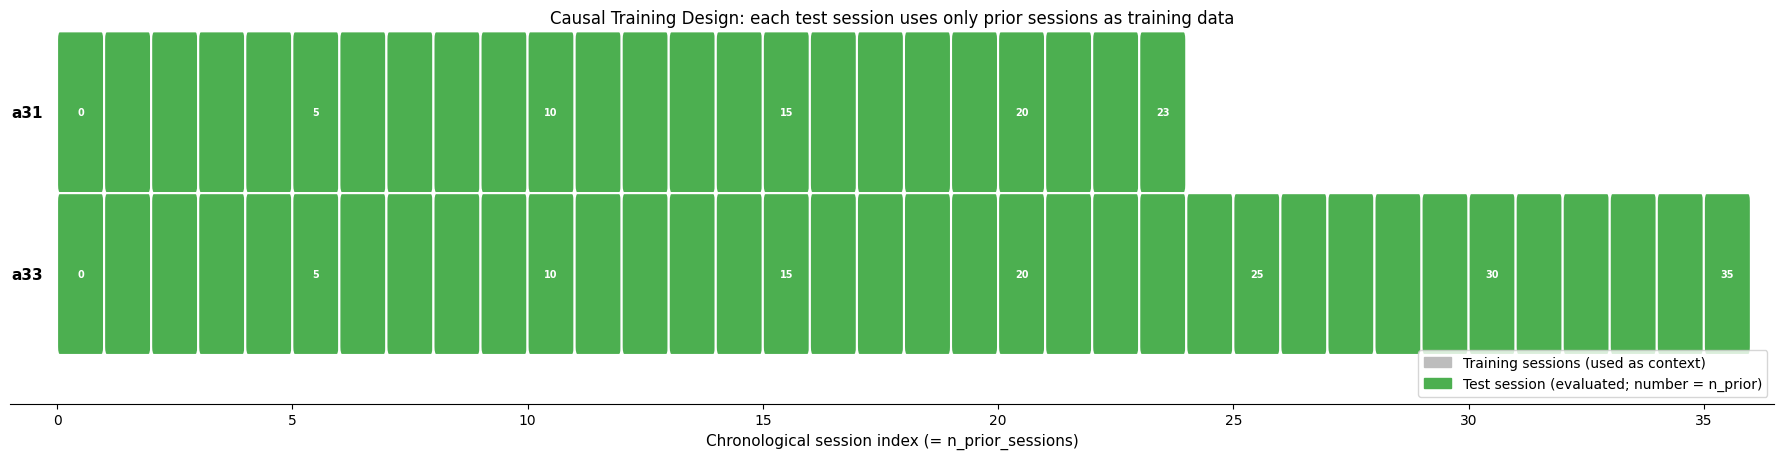

In [12]:
# --- Figure 1: Tile schematic of causal training design ---
if not CAUSAL_SECTION_OK:
    print('Section 3 skipped.')
else:
    # Build per-animal session info from the causal CSV
    # n_prior_sessions=k means k sessions used for training before this test session
    session_info = {}
    for anim, grp in df_causal.groupby('animal_ID'):
        sess_df = (grp.groupby('exp_moment')['n_prior_sessions'].first()
                     .reset_index()
                     .sort_values('n_prior_sessions')
                     .reset_index(drop=True))
        session_info[anim] = sess_df

    n_animals = len(session_info)
    max_sessions = max(len(v) for v in session_info.values())

    fig, ax = plt.subplots(figsize=(min(1.0 * max_sessions + 2, 18), n_animals * 1.6 + 1.5))

    for row_idx, (anim, sess_df) in enumerate(sorted(session_info.items())):
        y = n_animals - 1 - row_idx
        n_sess = len(sess_df)
        for col_idx, rec in sess_df.iterrows():
            n_prior = int(rec['n_prior_sessions'])
            # Training sessions (prior): gray; test session: green
            # Show training blocks first, then the test session
            # Each row: [train_0, train_1, ..., train_{n_prior-1}, TEST]
            # The x position = col_idx (chronological session index = n_prior)
            x = col_idx
            color = '#4caf50'  # green = test session
            ax.add_patch(mpatches.FancyBboxPatch(
                (x + 0.05, y + 0.05), 0.9, 0.9,
                boxstyle='round,pad=0.05',
                facecolor=color, edgecolor='white', linewidth=1.5
            ))
            # Annotate n_prior on every 5th or first/last
            if n_prior % 5 == 0 or col_idx == n_sess - 1:
                ax.text(x + 0.5, y + 0.5, str(n_prior),
                        ha='center', va='center', fontsize=7, color='white', fontweight='bold')

        # Show training tiles (gray) filling left of the last test tile
        # (Represent the cumulative training sessions as a gray background strip)
        for col_idx, rec in sess_df.iterrows():
            n_prior = int(rec['n_prior_sessions'])
            for train_idx in range(n_prior):
                ax.add_patch(mpatches.FancyBboxPatch(
                    (train_idx + 0.05, y + 0.1), 0.9, 0.8,
                    boxstyle='round,pad=0.02',
                    facecolor='#bdbdbd', edgecolor='white', linewidth=0.5,
                    zorder=0, alpha=0.3
                ))
            break  # only need the last row to show full training extent

        ax.text(-0.3, y + 0.5, f'a{anim}', ha='right', va='center',
                fontsize=11, fontweight='bold')

    # Legend
    train_patch = mpatches.Patch(color='#bdbdbd', label='Training sessions (used as context)')
    test_patch  = mpatches.Patch(color='#4caf50', label='Test session (evaluated; number = n_prior)')
    ax.legend(handles=[train_patch, test_patch], loc='lower right', fontsize=10)

    ax.set_xlim(-1.0, max_sessions + 0.5)
    ax.set_ylim(-0.3, n_animals)
    ax.set_xlabel('Chronological session index (= n_prior_sessions)', fontsize=11)
    ax.set_yticks([])
    ax.set_title(
        'Causal Training Design: each test session uses only prior sessions as training data',
        fontsize=12
    )
    ax.spines[['top', 'right', 'left']].set_visible(False)

    plt.tight_layout()
    plt.show()

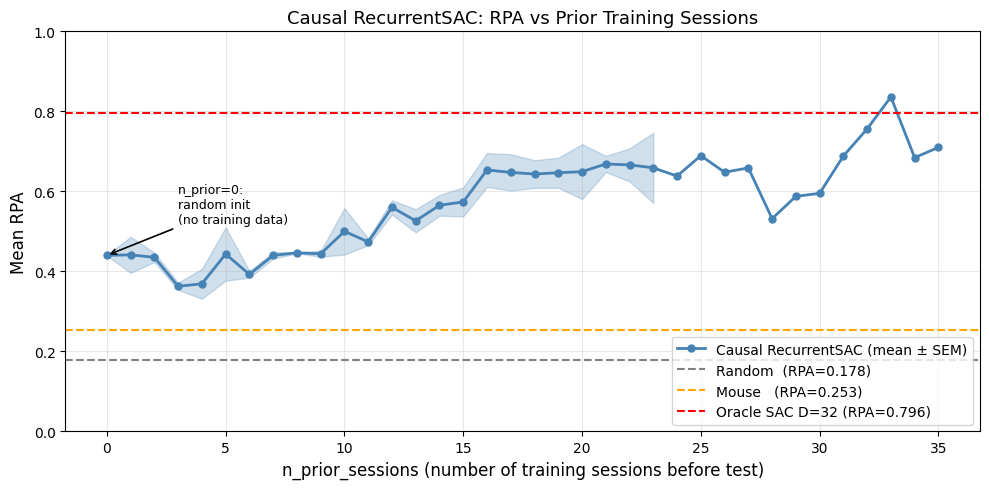

In [13]:
# --- Figure 2: Learning curve ---
if not CAUSAL_SECTION_OK:
    print('Section 3 skipped.')
else:
    # Mean per-session RPA over seeds, then pool across animals for each n_prior value
    sess_mean = (df_causal
                 .groupby(['n_prior_sessions', 'exp_moment'])['rpa']
                 .mean()
                 .reset_index()
                 .rename(columns={'rpa': 'mean_rpa'}))

    prior_stats = (sess_mean
                   .groupby('n_prior_sessions')['mean_rpa']
                   .agg(['mean', 'sem', 'count'])
                   .reset_index()
                   .rename(columns={'mean': 'mean_rpa', 'sem': 'sem_rpa',
                                    'count': 'n_sessions'}))

    fig, ax = plt.subplots(figsize=(10, 5))

    x  = prior_stats['n_prior_sessions'].values
    y  = prior_stats['mean_rpa'].values
    se = prior_stats['sem_rpa'].values

    ax.plot(x, y, color='steelblue', linewidth=2, marker='o', markersize=5,
            label='Causal RecurrentSAC (mean ± SEM)')
    ax.fill_between(x, y - se, y + se, color='steelblue', alpha=0.25)

    # Reference lines
    ax.axhline(RANDOM_RPA, color='gray',   linestyle='--', linewidth=1.5,
               label=f'Random  (RPA={RANDOM_RPA:.3f})')
    ax.axhline(MOUSE_RPA,  color='orange', linestyle='--', linewidth=1.5,
               label=f'Mouse   (RPA={MOUSE_RPA:.3f})')
    ax.axhline(ORACLE_SAC_RPA, color='red', linestyle='--', linewidth=1.5,
               label=f'Oracle SAC D=32 (RPA={ORACLE_SAC_RPA:.3f})')

    # Annotation for n_prior=0
    if len(x) > 0:
        y0 = prior_stats.loc[prior_stats['n_prior_sessions'] == 0, 'mean_rpa']
        if len(y0) > 0:
            ax.annotate(
                'n_prior=0:\nrandom init\n(no training data)',
                xy=(0, float(y0.iloc[0])),
                xytext=(3, float(y0.iloc[0]) + 0.08),
                fontsize=9,
                arrowprops=dict(arrowstyle='->', color='black', lw=1.2),
            )

    ax.set_xlabel('n_prior_sessions (number of training sessions before test)', fontsize=12)
    ax.set_ylabel('Mean RPA', fontsize=12)
    ax.set_title('Causal RecurrentSAC: RPA vs Prior Training Sessions', fontsize=13)
    ax.legend(fontsize=10, loc='lower right')
    ax.set_ylim(0, 1.0)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

---
## Section 4: Updated Agent Rankings

Incorporating the three new results into the benchmark table from the 260318 report.

In [14]:
# --- Compute updated RPA values ---

# OnlineBeliefBFS: use new fixed file if available, else fall back to reported value
if df_new is not None:
    belief_bfs_rpa = df_new['total_reward'].sum() / df_new['n_actions'].sum()
else:
    belief_bfs_rpa = 0.243  # from 260318 benchmark report
    print('OnlineBeliefBFS: using reported value 0.243 (fixed CSV not loaded)')

# Causal RecurrentSAC: use loaded data if available
if df_causal is not None:
    causal_sac_rpa = df_causal['rpa'].mean()
else:
    causal_sac_rpa = None
    print('Causal RecurrentSAC: DATA NOT YET AVAILABLE — omitted from table')

# --- Build updated rankings table ---
# Source: 260318-172522_comprehensive_benchmark.md
benchmark_data = [
    ('Greedy_oracle',             0.878, 'Heuristic (oracle)'),
    ('POMCP c=20 (fewer_sims)',   0.820, 'Planning (oracle)'),
    ('RecurrentSAC D=32 (oracle)', ORACLE_SAC_RPA, 'Meta-RL oracle (trains+tests on same sessions)'),
    ('POMCP c=1.0',               0.765, 'Planning (oracle)'),
    ('POMCP c=20 (full41)',       0.743, 'Planning (oracle)'),
    ('MOP_rw10',                  0.706, 'MOP'),
    ('MOP_rw5',                   0.682, 'MOP'),
    ('DQN pretrained',            0.527, 'Value + pretrain'),
    ('FSC_bio',                   0.503, 'Intermediate'),
    ('MOP_rw1',                   0.467, 'MOP'),
    ('DRQN_seq pretrained',       0.426, 'Recurrent + pretrain'),
    ('DRQN_rand pretrained',      0.426, 'Recurrent + pretrain'),
    ('Random_forward',            0.385, 'Heuristic'),
    ('DRQN_seq (HPO-best)',        0.368, 'Recurrent'),
    ('DQN (HPO-best)',             0.362, 'Value-based'),
    ('DRQN_rand (HPO-best)',       0.313, 'Recurrent'),
    ('Mouse',                     MOUSE_RPA, 'Biological'),
    ('QRDQN (HPO-best)',           0.248, 'Value-based'),
    ('TRPO (HPO-best)',            0.243, 'Policy-gradient'),
    ('OnlineBeliefBFS (fixed)',   belief_bfs_rpa, 'Belief state (online, no oracle)'),
    ('POMCP_bio',                  0.209, 'Planning (bio)'),
    ('PPO (HPO-best)',             0.199, 'Policy-gradient'),
    ('A2C (HPO-best)',             0.197, 'Policy-gradient'),
    ('OOI',                        0.184, 'Intermediate'),
    ('VarMarkov',                  0.183, 'Intermediate'),
    ('Random',                     0.178, 'Heuristic'),
    ('RecurrentPPO (HPO-best)',    0.171, 'Recurrent'),
    ('MOP',                        0.129, 'MOP'),
]

if causal_sac_rpa is not None:
    benchmark_data.append(
        ('RecurrentSAC causal', causal_sac_rpa, 'Meta-RL (causally valid)')
    )

df_bench = pd.DataFrame(benchmark_data, columns=['Agent', 'RPA', 'Family'])
df_bench['pct_ceiling'] = df_bench['RPA'].apply(pct_ceiling)
df_bench = df_bench.sort_values('RPA', ascending=False).reset_index(drop=True)
df_bench.index += 1

# --- Print markdown table ---
print('## Updated Benchmark Rankings (as of 2026-03-27)')
print()
print(f'{"Rank":>4}  {"Agent":<38}  {"RPA":>6}  {"% Ceiling":>10}  Family')
print('-' * 90)
for rank, row in df_bench.iterrows():
    tag = ''
    if row['Agent'] == 'OnlineBeliefBFS (fixed)':
        tag = '  ← issue fix'
    elif row['Agent'] == 'RecurrentSAC causal':
        tag = '  ← NEW (causal)'
    print(f'{rank:>4}  {row["Agent"]:<38}  {row["RPA"]:>6.3f}  '
          f'{row["pct_ceiling"]:>9.1f}%  {row["Family"]}{tag}')
print()
print('Notes:')
print(f'  OnlineBeliefBFS: old (broken) RPA=0.243; fixed RPA={belief_bfs_rpa:.3f}')
if causal_sac_rpa is not None:
    print(f'  RecurrentSAC causal: RPA={causal_sac_rpa:.3f}  ({pct_ceiling(causal_sac_rpa):.1f}% ceiling)')
    print(f'  Oracle SAC leakage delta: {ORACLE_SAC_RPA - causal_sac_rpa:+.3f}')

## Updated Benchmark Rankings (as of 2026-03-27)

Rank  Agent                                      RPA   % Ceiling  Family
------------------------------------------------------------------------------------------
   1  Greedy_oracle                            0.878      100.0%  Heuristic (oracle)
   2  POMCP c=20 (fewer_sims)                  0.820       91.7%  Planning (oracle)
   3  RecurrentSAC D=32 (oracle)               0.796       88.3%  Meta-RL oracle (trains+tests on same sessions)
   4  POMCP c=1.0                              0.765       83.9%  Planning (oracle)
   5  POMCP c=20 (full41)                      0.743       80.7%  Planning (oracle)
   6  MOP_rw10                                 0.706       75.4%  MOP
   7  MOP_rw5                                  0.682       72.0%  MOP
   8  RecurrentSAC causal                      0.555       53.9%  Meta-RL (causally valid)  ← NEW (causal)
   9  DQN pretrained                           0.527       49.9%  Value + pretrain
  10  